Install Libraries

In [1]:
!pip install -q medmnist torch torchvision matplotlib seaborn scikit-learn torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.2 MB/s eta 0:00:00


Import Libraries and set Device

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms, datasets
from medmnist import BreastMNIST
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from torchinfo import summary
import os
import random
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import torch
from typing import Dict
import torch.nn.utils as utils



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Set seet to stop variation in results

In [3]:

def set_seed(seed=42):
    """Sets the seed for reproducibility across all libraries."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"Random seed set to: {seed}")

set_seed(42)

Random seed set to: 42


Load and organize the dataset into specified subfolders

In [4]:

base_dir = "breast_mnist_images"

def extract_and_save(dataset, split_name):
    print(f"Creating folders and saving {split_name} data...")
    for i in range(len(dataset)):
        # The raw medmnist dataset returns a PIL Image and an array containing the label
        img, label = dataset[i]
        class_id = label[0]

        # Create the directory structure: base_dir / split / class_id
        folder_path = os.path.join(base_dir, split_name, str(class_id))
        os.makedirs(folder_path, exist_ok=True)

        # Save the image into its specific folder
        img_path = os.path.join(folder_path, f"{split_name}_img_{i}.jpg")
        img.save(img_path)

#Load the RAW datasets
raw_train = BreastMNIST(split="train", download=True)
raw_val = BreastMNIST(split="val", download=True)
raw_test = BreastMNIST(split="test", download=True)

extract_and_save(raw_train, "train")
extract_and_save(raw_val, "val")
extract_and_save(raw_test, "test")


100%|██████████| 560k/560k [00:00<00:00, 593kB/s]


Creating folders and saving train data...
Creating folders and saving val data...
Creating folders and saving test data...


create train,val,test datasets and dataloaders

In [5]:

data_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_dir = "breast_mnist_images"

# Load datasets directly from the newly created folders
train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), transform=data_transform)
val_dataset = datasets.ImageFolder(os.path.join(base_dir, 'val'), transform=data_transform)
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), transform=data_transform)

# Package into DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

visualize some samples from dataset to see what kind of data we have

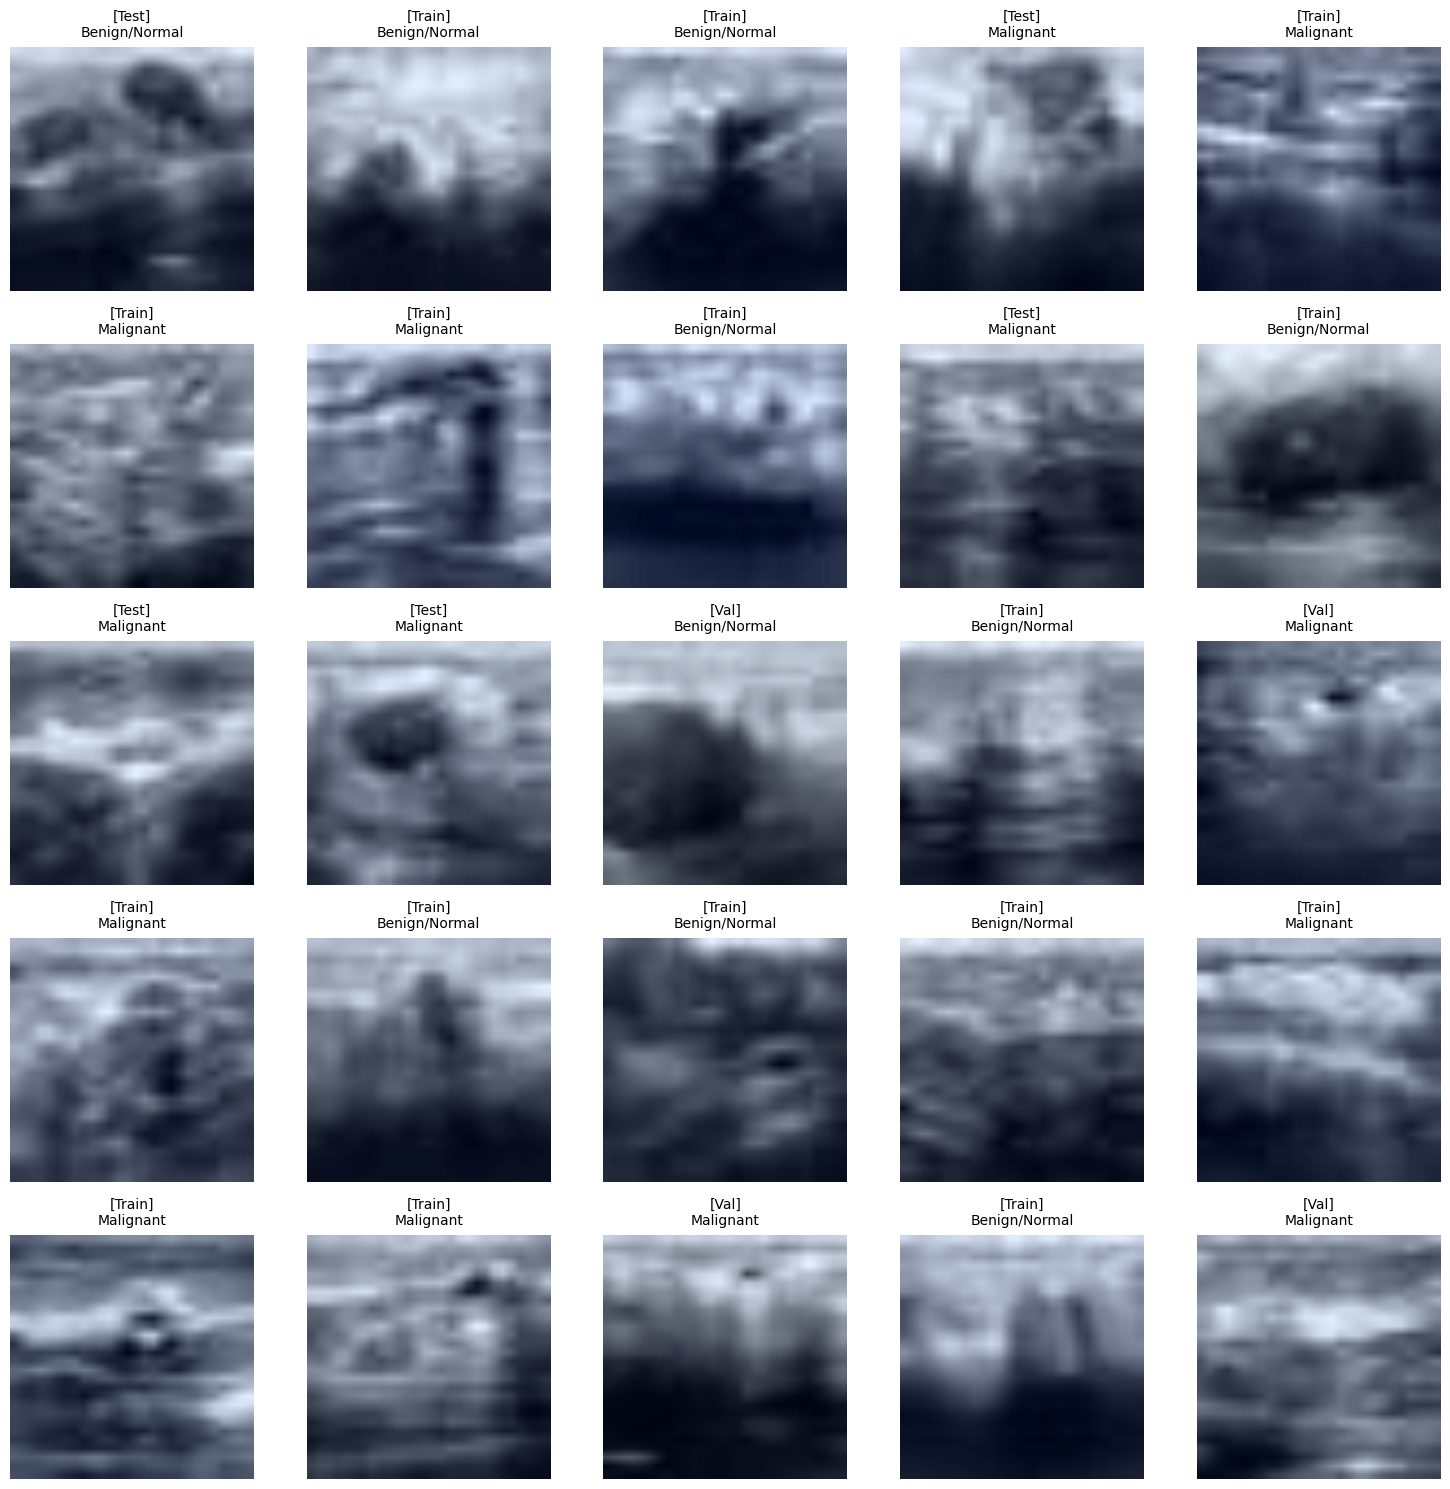

In [6]:

def visualize_dataset_samples(train_set, val_set, test_set):
    # 1. Combine datasets into a single list with a tracking tag
    # Each item in the pool is a tuple: (image_tensor, label, split_tag)
    pool = []
    pool.extend([(img, lbl, "Train") for img, lbl in train_set])
    pool.extend([(img, lbl, "Val") for img, lbl in val_set])
    pool.extend([(img, lbl, "Test") for img, lbl in test_set])

    # 2. Randomly select 25 unique samples for our 5x5 grid
    if len(pool) < 25:
        raise ValueError("Not enough images in the dataset to create a 5x5 grid.")
    samples = random.sample(pool, 25)

    # 3. Class names for BreastMNIST: 0 is 'benign' (normal/benign), 1 is 'malignant'
    # For BreastMNIST, 0 = benign, 1 = malignant
    class_names = {0: "Benign/Normal", 1: "Malignant"}

    # 4. Initialize the 5x5 matplotlib figure
    fig, axes = plt.subplots(5, 5, figsize=(15, 15))
    axes = axes.flatten() # Flatten 2D array of axes to 1D for easy iteration

    for i, (img_tensor, label, split) in enumerate(samples):
        ax = axes[i]

        # PyTorch tensors are (Channels, Height, Width)
        # Matplotlib expects (Height, Width, Channels) for plotting
        # We also need to un-normalize the image if we want to view it realistically,
        # but since we just want to inspect the structure, a basic permutation or clip works:
        img_array = img_tensor.permute(1, 2, 0).numpy()
        # Clip values to [0, 1] range to avoid matplotlib warnings if values went slightly out of bounds due to normalization
        img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min() + 1e-8)



        ax.imshow(img_array)
        ax.axis('off')
        class_name = class_names.get(label, f"Class {label}")
        ax.set_title(f"[{split}]\n{class_name}", fontsize=10, pad=8)

    plt.tight_layout()
    plt.show()

visualize_dataset_samples(train_dataset, val_dataset, test_dataset)

checking the class imbalance issue; most of the medical datasets have this problem

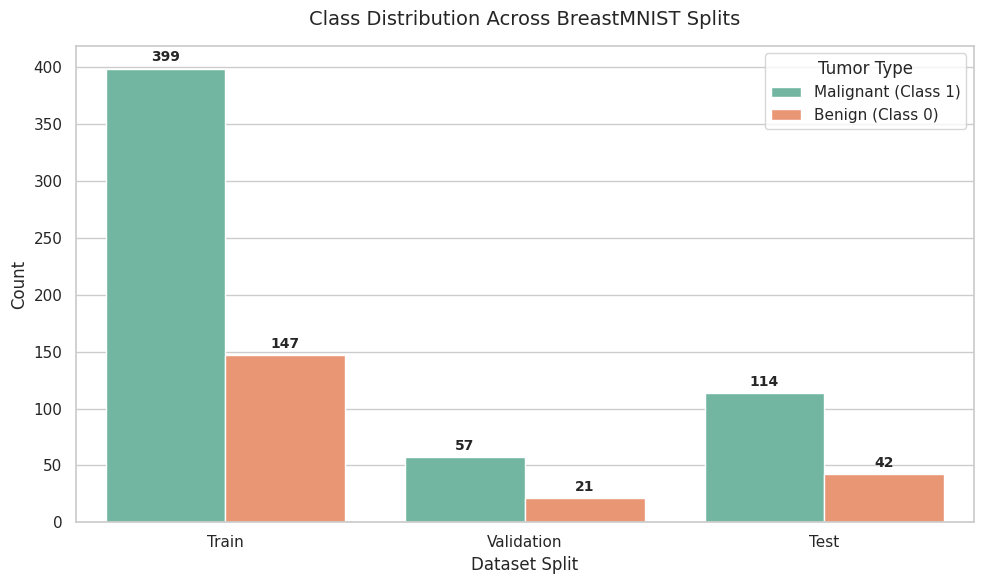

In [7]:

def get_label_counts(dataset, split_name):
    # Iterate through the dataset and extract the label
    labels = []
    for _, label in dataset:
        # Handle both raw MedMNIST arrays and standard PyTorch integer labels
        if isinstance(label, list) or hasattr(label, '__iter__'):
            labels.append(label[0])
        else:
            labels.append(label)

    # Count occurrences of each class
    return pd.Series(labels).value_counts().rename(split_name)


train_counts = get_label_counts(train_dataset, 'Train')
val_counts = get_label_counts(val_dataset, 'Validation')
test_counts = get_label_counts(test_dataset, 'Test')

#  Combine the counts into a single DataFrame
df = pd.concat([train_counts, val_counts, test_counts], axis=1).fillna(0).astype(int)

# Map the numerical indices to their clinical names
df.index = ['Malignant (Class 1)' if i == 1 else 'Benign (Class 0)' for i in df.index]

# Reshape the data for Seaborn
df_melted = df.reset_index().melt(id_vars='index', var_name='Split', value_name='Number of Images')
df_melted.rename(columns={'index': 'Tumor Type'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=df_melted, x='Split', y='Number of Images', hue='Tumor Type', palette='Set2')

plt.title('Class Distribution Across BreastMNIST Splits', fontsize=14, pad=15)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Dataset Split', fontsize=12)

# Add the exact number on top of each bar for clarity
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

check dataset info to realize what the size of our images tensors are and make sure our transformation is applied.

In [8]:
def print_dataset_info(dataset, split_name):
    print(f"--- {split_name.upper()} DATASET INFO ---")

    # 1. Total number of samples
    num_samples = len(dataset)
    print(f"Total Images: {num_samples}")

    # 2. Inspect the first image and label
    first_image, first_label = dataset[0]

    # 3. Image Shape / Dimensions
    # PyTorch tensors are in [Channels, Height, Width] format
    print(f"Image Tensor Shape: {first_image.shape}")

    # 4. Data Type
    print(f"Data Type: {first_image.dtype}")

    # 5. Class Information
    if hasattr(dataset, 'class_to_idx'):
        print(f"Classes Found: {dataset.classes}")
    else:
        # Fallback for raw MedMNIST dataset
        print(f"Sample Label Format: {first_label}")

    print("-" * 30 + "\n")

print_dataset_info(train_dataset, "Train")
print_dataset_info(val_dataset, "Validation")
print_dataset_info(test_dataset, "Test")

total_images = len(train_dataset) + len(val_dataset) + len(test_dataset)
print(f"Total Images Across All Splits: {total_images}")

--- TRAIN DATASET INFO ---
Total Images: 546
Image Tensor Shape: torch.Size([3, 224, 224])
Data Type: torch.float32
Classes Found: ['0', '1']
------------------------------

--- VALIDATION DATASET INFO ---
Total Images: 78
Image Tensor Shape: torch.Size([3, 224, 224])
Data Type: torch.float32
Classes Found: ['0', '1']
------------------------------

--- TEST DATASET INFO ---
Total Images: 156
Image Tensor Shape: torch.Size([3, 224, 224])
Data Type: torch.float32
Classes Found: ['0', '1']
------------------------------

Total Images Across All Splits: 780


Load resnet18 with pretrained weights and change the head to be matched with our dataset

In [19]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Change the last layer of the model to recognize 2 classes of our data (by default it recognizes 1000 classes)
num_ftrs = model.fc.in_features
num_classes = len(train_dataset.classes)
print(f"Number of classes recognized: {num_classes}")
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

Number of classes recognized: 2


Exporting a summary of our model Structure

In [20]:

# pass an input size matching our DataLoader: (batch_size, channels, height, width)
summary(model, input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    └─BasicBlock (0)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     36,864               True
│    │    └─BatchN

Training, Vlidating, and saving best model

In [ ]:

epochs = 10
train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')
for epoch in range(epochs):
    model.train()
    running_corrects = 0
    running_loss = 0.0
    total_train = 0


    for inputs, targets in train_loader:

        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == targets)
        running_loss += loss.item() * inputs.size(0)
        total_train += targets.size(0)

    train_acc = running_corrects.double() / total_train
    train_loss = running_loss / total_train

    train_acc_history.append(train_acc.item())
    train_loss_history.append(train_loss)

    model.eval()
    val_corrects = 0
    val_loss = 0.0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == targets)
            val_loss += loss.item() * inputs.size(0)
            total_val += targets.size(0)

    val_acc = val_corrects.double() / total_val
    epoch_val_loss = val_loss / total_val

    val_acc_history.append(val_acc.item())
    val_loss_history.append(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f}')
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_breast_mnist_model_resnet.pth')
        print(" -> Best model saved!")

Load best model and have a validation on test set

In [22]:


model.load_state_dict(torch.load('best_breast_mnist_model_resnet.pth'))

model.eval()
test_corrects = 0
total_test = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        test_corrects += torch.sum(preds == targets)
        total_test += targets.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

test_acc = test_corrects.double() / total_test
print(f'Test Accuracy (Best Model): {test_acc:.4f}')

Test Accuracy (Best Model): 0.8590


Classification report and visualization

In [ ]:

print("\n--- Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=['Benign (0)', 'Malignant (1)']))
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual benign'])
plt.title('Test Set Confusion Matrix')
plt.show()

Visualize and Validation

In [ ]:

sns.set_theme(style="whitegrid", palette="deep")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
epochs_range = range(1, epochs + 1)

ax1.plot(epochs_range, train_acc_history, label='Train Accuracy', marker='o', linewidth=2.5, markersize=7)
ax1.plot(epochs_range, val_acc_history, label='Validation Accuracy', marker='s', linewidth=2.5, markersize=7)

best_acc_epoch = np.argmax(val_acc_history) + 1
best_acc = max(val_acc_history)
ax1.scatter(best_acc_epoch, best_acc, s=200, facecolors='none', edgecolors='green',
            linewidth=2, zorder=5, label=f'Best Accuracy ({best_acc:.2f})')

ax1.set_title('ResNet18 Accuracy', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=13)
ax1.set_ylabel('Accuracy', fontsize=13)
ax1.set_xticks(epochs_range)
ax1.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)


ax2.plot(epochs_range, train_loss_history, label='Train Loss', marker='o', linewidth=2.5, markersize=7)
ax2.plot(epochs_range, val_loss_history, label='Validation Loss', marker='s', linewidth=2.5, markersize=7)

best_loss_epoch = np.argmin(val_loss_history) + 1
best_loss = min(val_loss_history)
ax2.scatter(best_loss_epoch, best_loss, s=200, facecolors='none', edgecolors='red',
            linewidth=2, zorder=5, label=f'Best Model Saved ({best_loss:.2f})')

ax2.set_title('ResNet18 Cross-Entropy Loss', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=13)
ax2.set_ylabel('Loss', fontsize=13)
ax2.set_xticks(epochs_range)
ax2.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)


fig.suptitle('BreastMNIST Training Performance Dashboard', fontsize=20, fontweight='black', y=1.05)

plt.tight_layout()
plt.show()

smooth

In [14]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_ftrs = model.fc.in_features
num_classes = len(train_dataset.classes)
print(f"Number of classes recognized: {num_classes}")
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)


In [ ]:
epochs = 10
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    running_corrects = 0
    running_loss = 0.0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == targets)
        running_loss += loss.item() * inputs.size(0)
        total_train += targets.size(0)

    train_acc = running_corrects.double() / total_train
    train_loss = running_loss / total_train

    train_acc_history.append(train_acc.item())
    train_loss_history.append(train_loss)

    model.eval()
    val_corrects = 0
    val_loss = 0.0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == targets)
            val_loss += loss.item() * inputs.size(0)
            total_val += targets.size(0)

    val_acc = val_corrects.double() / total_val
    epoch_val_loss = val_loss / total_val

    val_acc_history.append(val_acc.item())
    val_loss_history.append(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss

        torch.save(model.state_dict(), 'best_breast_mnist_model_resnet_smoothed.pth')
        print("Best smoothed model saved!")

In [ ]:
model.load_state_dict(torch.load('best_breast_mnist_model_resnet_smoothed.pth'))

model.eval()
test_corrects = 0
total_test = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        test_corrects += torch.sum(preds == targets)
        total_test += targets.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

test_acc = test_corrects.double() / total_test
print(f'Test Accuracy (Smoothed Model): {test_acc:.4f}')

In [ ]:
test_acc = test_corrects.double() / total_test
print(f'Test Accuracy (Smoothed Model): {test_acc:.4f}')

print("\n--- Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=['Benign (0)', 'Malignant (1)']))
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted bemign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Test Set Confusion Matrix (Label Smoothed)')
plt.show()

C DCGANS

In [15]:
class ConditionalGenerator(nn.Module):
    def __init__(self, num_classes: int, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim

        self.label_embedding = nn.Embedding(num_classes, latent_dim)

        self.fc_block = nn.Sequential(
            nn.Linear(latent_dim * 2, 6272),
            nn.BatchNorm1d(6272),
            nn.ReLU(inplace=True)
        )

        self.conv_blocks = nn.Sequential(

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),


            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        embedded_labels = self.label_embedding(labels)
        x = torch.cat([noise, embedded_labels], dim=1)
        x = self.fc_block(x)
        x = x.view(-1, 128, 7, 7)
        return self.conv_blocks(x)

In [59]:
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm

class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.label_embedding = nn.Embedding(num_classes, 784)

        self.conv_blocks = nn.Sequential(

            spectral_norm(nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3)
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6272, 1),
            nn.Sigmoid()
        )

    def forward(self, img: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        embedded_labels = self.label_embedding(labels).view(-1, 1, 28, 28)
        x = torch.cat([img, embedded_labels], dim=1)
        x = self.conv_blocks(x)
        return self.fc_block(x)

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Dict

class CDCModel:
    """
    Wrapper class managing the initialization, hyperparameter configurations,
    and adversarial training loop steps for the cDCGAN framework.
    """

    def __init__(self, num_classes: int, latent_dim: int, lr_g: float = 0.0002,
                 lr_d: float = 0.0003, beta1: float = 0.5, device: str = "cuda"):

        self.device = torch.device(device if torch.cuda.is_available() else "cpu")
        self.latent_dim = latent_dim

        # Instantiate networks based on our customized classes
        self.generator = ConditionalGenerator(
            num_classes=num_classes,
            latent_dim=latent_dim
        ).to(self.device)

        self.discriminator = ConditionalDiscriminator(
            num_classes=num_classes
        ).to(self.device)

        # Apply formal weights initialization pass
        self.generator.apply(self._weights_init)
        self.discriminator.apply(self._weights_init)

        # Loss and Optimizers
        self.criterion = nn.BCELoss()

        self.opt_G = optim.Adam(self.generator.parameters(), lr=lr_g, betas=(beta1, 0.999))
        self.opt_D = optim.Adam(self.discriminator.parameters(), lr=lr_d, betas=(beta1, 0.999))

    @staticmethod
    def _weights_init(m: nn.Module) -> None:
        """Applies formal normal weight initializations to convolutional blocks."""
        classname = m.__class__.__name__
        if classname.find('Conv') != -1:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif classname.find('BatchNorm') != -1:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

    def train_step(self, real_imgs: torch.Tensor, labels: torch.Tensor) -> Dict[str, float]:
        """
        Executes a highly balanced adversarial training step.
        """
        batch_size = real_imgs.size(0)


        valid = torch.full((batch_size, 1),1.0, device=self.device)
        fake = torch.zeros((batch_size, 1), device=self.device)

        real_imgs = real_imgs.to(self.device)
        labels = labels.to(self.device)


        #  Train Discriminator
        self.opt_D.zero_grad()

        validity_real = self.discriminator(real_imgs, labels)
        d_real_loss = self.criterion(validity_real, valid)

        z = torch.randn(batch_size, self.latent_dim, device=self.device)
        gen_imgs = self.generator(z, labels)
        validity_fake = self.discriminator(gen_imgs.detach(), labels)
        d_fake_loss = self.criterion(validity_fake, fake)

        d_loss = (d_real_loss + d_fake_loss) / 2

        d_loss.backward()
        self.opt_D.step()


        #  Train Generator
        self.opt_G.zero_grad()

        valid_g = torch.ones((batch_size, 1), device=self.device)

        validity_gen = self.discriminator(gen_imgs, labels)
        g_loss = self.criterion(validity_gen, valid_g)

        g_loss.backward()
        self.opt_G.step()

        return {"d_loss": d_loss.item(), "g_loss": g_loss.item()}

    def generate(self, num_samples: int, class_label: int) -> torch.Tensor:
        """Generates synthetic evaluations for testing or sampling checks."""
        self.generator.eval()
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim, device=self.device)
            labels = torch.full((num_samples,), class_label, dtype=torch.long, device=self.device)
            generated_imgs = self.generator(z, labels)
        self.generator.train()
        return generated_imgs

In [61]:
from torchinfo import summary

gan = CDCModel(
    num_classes=2,
    latent_dim=100,
    device="cuda"
)

print("GENERATOR ARCHITECTURE:\n")

summary(gan.generator, input_data=[torch.randn(32, 100).to(gan.device), torch.randint(0, 2, (32,)).to(gan.device)],
        col_names=["input_size", "output_size", "num_params", "trainable"])


GENERATOR ARCHITECTURE:



Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ConditionalGenerator                     [32, 100]                 [32, 1, 28, 28]           --                        True
├─Embedding: 1-1                         [32]                      [32, 100]                 200                       True
├─Sequential: 1-2                        [32, 200]                 [32, 6272]                --                        True
│    └─Linear: 2-1                       [32, 200]                 [32, 6272]                1,260,672                 True
│    └─BatchNorm1d: 2-2                  [32, 6272]                [32, 6272]                12,544                    True
│    └─ReLU: 2-3                         [32, 6272]                [32, 6272]                --                        --
├─Sequential: 1-3                        [32, 128, 7, 7]           [32, 1, 28, 28]           --                        True
│    

In [62]:
print("DISCRIMINATOR ARCHITECTURE:\n")
summary(gan.discriminator, input_data=[torch.randn(32, 1, 28, 28).to(gan.device), torch.randint(0, 2, (32,)).to(gan.device)],
        col_names=["input_size", "output_size", "num_params", "trainable"])

DISCRIMINATOR ARCHITECTURE:



Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ConditionalDiscriminator                 [32, 1, 28, 28]           [32, 1]                   --                        True
├─Embedding: 1-1                         [32]                      [32, 784]                 1,568                     True
├─Sequential: 1-2                        [32, 2, 28, 28]           [32, 128, 7, 7]           --                        True
│    └─Conv2d: 2-1                       [32, 2, 28, 28]           [32, 64, 14, 14]          2,048                     True
│    └─LeakyReLU: 2-2                    [32, 64, 14, 14]          [32, 64, 14, 14]          --                        --
│    └─Dropout: 2-3                      [32, 64, 14, 14]          [32, 64, 14, 14]          --                        --
│    └─Conv2d: 2-4                       [32, 64, 14, 14]          [32, 128, 7, 7]           131,072                   True
│    └─

In [63]:



data_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data_transform_augment = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
base_dir = "breast_mnist_images"

train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), transform=data_transform_augment)
val_dataset = datasets.ImageFolder(os.path.join(base_dir, 'val'), transform=data_transform)
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), transform=data_transform)

batch_size = 32
# Drop_last=True is highly recommended in GANs to avoid batch normalization issues with small final batches
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [64]:
import os
import torch

def evaluate_gan_balance(gan, val_loader, device):
    """
    Validation step: Calculates how close the GAN is to the ideal Nash Equilibrium.
    """
    gan.generator.eval()
    gan.discriminator.eval()

    total_real_prob = 0.0
    total_fake_prob = 0.0
    num_batches = 0

    with torch.no_grad():
        for real_imgs, labels in val_loader:
            real_imgs = real_imgs.to(device)
            labels = labels.to(device)
            batch_size = real_imgs.size(0)

            # Discriminator's average prediction on REAL images
            real_preds = gan.discriminator(real_imgs, labels)
            total_real_prob += real_preds.mean().item()

            # Discriminator's average prediction on FAKE images
            z = torch.randn(batch_size, gan.latent_dim, device=device)
            fake_imgs = gan.generator(z, labels)
            fake_preds = gan.discriminator(fake_imgs, labels)
            total_fake_prob += fake_preds.mean().item()

            num_batches += 1

    avg_real_prob = total_real_prob / num_batches
    avg_fake_prob = total_fake_prob / num_batches

    # Ideal equilibrium is 0.5 for both. Lower score means closer to ideal (Best Model).
    balance_score = abs(avg_real_prob - 0.5) + abs(avg_fake_prob - 0.5)

    gan.generator.train()
    gan.discriminator.train()

    return avg_real_prob, avg_fake_prob, balance_score


def train_cDCGAN(gan, train_loader, val_loader, epochs: int, device: str):

    save_dir = "checkpoints"
    os.makedirs(save_dir, exist_ok=True)
    best_balance_score = float('inf')

    print(f"Starting Training for {epochs} Epochs on {device}...\n")

    for epoch in range(epochs):

        epoch_d_loss = 0.0
        epoch_g_loss = 0.0

        for real_imgs, labels in train_loader:

            losses = gan.train_step(real_imgs, labels)

            epoch_d_loss += losses['d_loss']
            epoch_g_loss += losses['g_loss']

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        real_prob, fake_prob, balance_score = evaluate_gan_balance(gan, val_loader, device)

        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

        print(f"  -> Val D(Real): {real_prob:.4f} | Val D(Fake): {fake_prob:.4f} | Balance Score: {balance_score:.4f}")

        checkpoint_data = {
            'epoch': epoch + 1,
            'generator_state_dict': gan.generator.state_dict(),
            'discriminator_state_dict': gan.discriminator.state_dict(),
            'd_loss': avg_d_loss,
            'g_loss': avg_g_loss,
            'balance_score': balance_score
        }

        # Save EVERY epoch
        epoch_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch+1}.pth")
        torch.save(checkpoint_data, epoch_path)

        # Save LAST model (overwrites previous)
        last_path = os.path.join(save_dir, "last_model.pth")
        torch.save(checkpoint_data, last_path)

        # Save BEST model
        if balance_score < best_balance_score:
            best_balance_score = balance_score
            best_path = os.path.join(save_dir, "best_model.pth")
            torch.save(checkpoint_data, best_path)
            print(f"   New Best Model Saved! (Score: {best_balance_score:.4f})\n")
        else:
            print("")


epochs = 500
device = "cuda" if torch.cuda.is_available() else "cpu"
train_cDCGAN(gan, train_loader, val_loader, epochs, device)

Starting Training for 500 Epochs on cuda...

Epoch [1/500] | D Loss: 0.6711 | G Loss: 0.7218
  -> Val D(Real): 0.5205 | Val D(Fake): 0.5020 | Balance Score: 0.0226
   New Best Model Saved! (Score: 0.0226)

Epoch [2/500] | D Loss: 0.7096 | G Loss: 0.7168
  -> Val D(Real): 0.4715 | Val D(Fake): 0.4823 | Balance Score: 0.0462

Epoch [3/500] | D Loss: 0.7079 | G Loss: 0.7184
  -> Val D(Real): 0.5380 | Val D(Fake): 0.5281 | Balance Score: 0.0661

Epoch [4/500] | D Loss: 0.6849 | G Loss: 0.7215
  -> Val D(Real): 0.4619 | Val D(Fake): 0.4625 | Balance Score: 0.0755

Epoch [5/500] | D Loss: 0.7020 | G Loss: 0.7437
  -> Val D(Real): 0.5241 | Val D(Fake): 0.5163 | Balance Score: 0.0404

Epoch [6/500] | D Loss: 0.6907 | G Loss: 0.7157
  -> Val D(Real): 0.4877 | Val D(Fake): 0.4894 | Balance Score: 0.0229

Epoch [7/500] | D Loss: 0.6882 | G Loss: 0.7108
  -> Val D(Real): 0.5329 | Val D(Fake): 0.5286 | Balance Score: 0.0615

Epoch [8/500] | D Loss: 0.7051 | G Loss: 0.7129
  -> Val D(Real): 0.4724 |

Successfully loaded weights from 'checkpoints/last_model.pth' (Epoch 500)!

Generating 2000 samples for Class 0 (Benign)...
Generating 2000 samples for Class 1 (Malignant)...


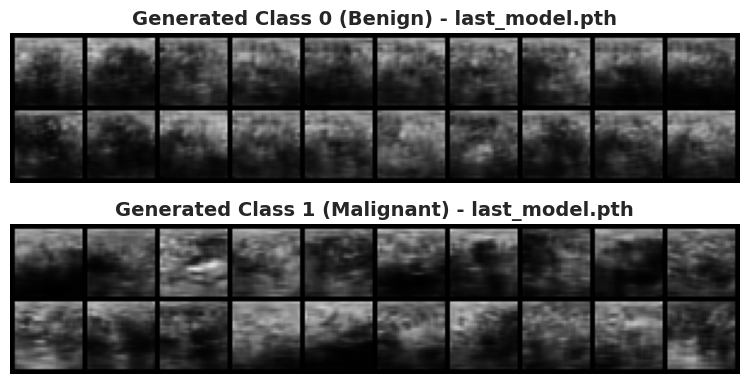


Extracting loss history from checkpoints...


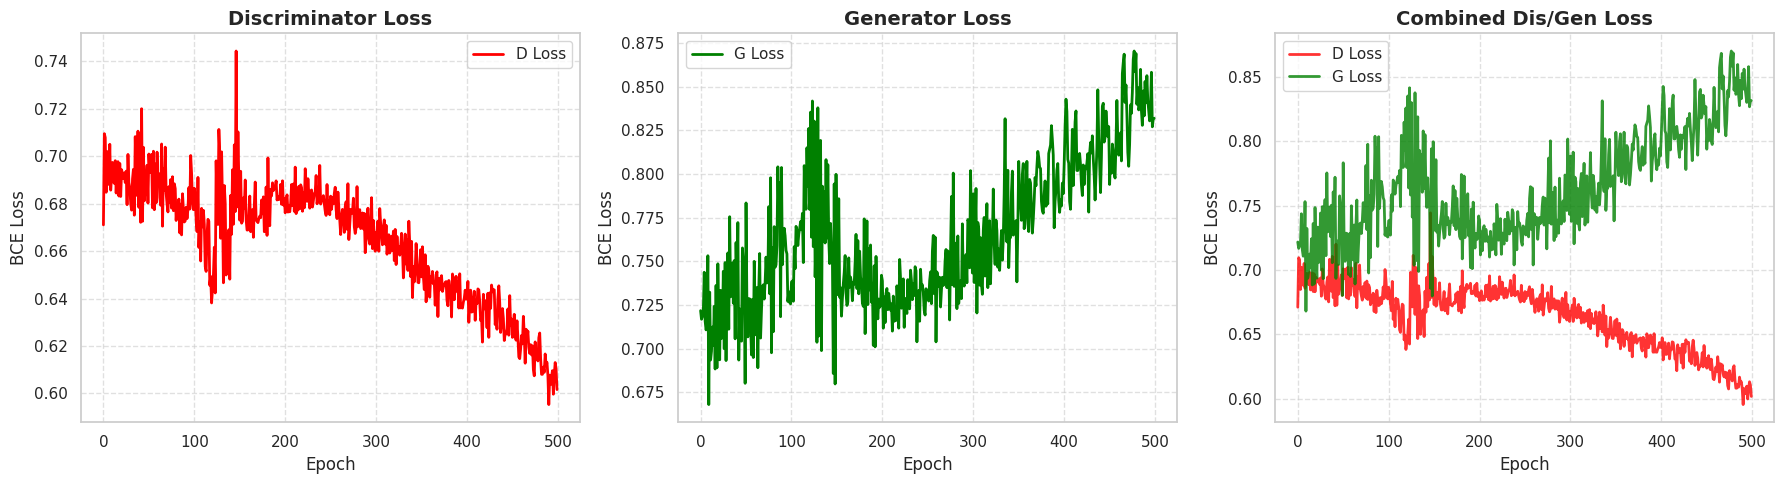

In [65]:
import os
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

eval_generator = ConditionalGenerator(
    num_classes=2,
    latent_dim=100
).to(device)

checkpoint_path = 'checkpoints/last_model.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)

eval_generator.load_state_dict(checkpoint['generator_state_dict'])
eval_generator.eval()

print(f"Successfully loaded weights from '{checkpoint_path}' (Epoch {checkpoint.get('epoch', 'N/A')})!")



NUM_SAMPLES_PER_CLASS = 2000

def generate_class_samples(generator, num_samples, class_label, latent_dim, device):
    """Generates synthetic samples for a specific class label."""
    with torch.no_grad():

        z = torch.randn(num_samples, latent_dim, dtype=torch.float32, device=device)
        labels = torch.full((num_samples,), class_label, dtype=torch.long, device=device)
        generated_imgs = generator(z, labels)
    return generated_imgs

print(f"\nGenerating {NUM_SAMPLES_PER_CLASS} samples for Class 0 (Benign)...")
fake_class_0 = generate_class_samples(eval_generator, NUM_SAMPLES_PER_CLASS, 0, 100, device)

print(f"Generating {NUM_SAMPLES_PER_CLASS} samples for Class 1 (Malignant)...")
fake_class_1 = generate_class_samples(eval_generator, NUM_SAMPLES_PER_CLASS, 1, 100, device)


def plot_random_images(fake_0, fake_1, model_name):

    idx_0 = torch.randperm(fake_0.size(0))[:20]
    idx_1 = torch.randperm(fake_1.size(0))[:20]

    sample_0 = fake_0[idx_0].cpu()
    sample_1 = fake_1[idx_1].cpu()

    # Un-normalize from [-1, 1] to [0, 1] for matplotlib
    sample_0 = (sample_0 + 1) / 2.0
    sample_1 = (sample_1 + 1) / 2.0


    grid_0 = vutils.make_grid(sample_0, nrow=10, padding=2, normalize=False)
    grid_1 = vutils.make_grid(sample_1, nrow=10, padding=2, normalize=False)

    fig, axes = plt.subplots(2, 1, figsize=(16, 4))

    axes[0].imshow(np.transpose(grid_0.numpy(), (1, 2, 0)), cmap='gray')
    axes[0].set_title(f"Generated Class 0 (Benign) - {model_name}", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(np.transpose(grid_1.numpy(), (1, 2, 0)), cmap='gray')
    axes[1].set_title(f"Generated Class 1 (Malignant) - {model_name}", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

plot_random_images(fake_class_0, fake_class_1, os.path.basename(checkpoint_path))


def extract_and_plot_losses(checkpoints_dir="checkpoints", num_epochs=300):
    """
    Automatically reads the saved epoch checkpoints to extract and plot loss history.
    """
    d_losses = []
    g_losses = []

    print("\nExtracting loss history from checkpoints...")
    for epoch in range(1, num_epochs + 1):
        epoch_path = os.path.join(checkpoints_dir, f"checkpoint_epoch_{epoch}.pth")
        if os.path.exists(epoch_path):
            chkpt = torch.load(epoch_path, map_location='cpu')
            d_losses.append(chkpt['d_loss'])
            g_losses.append(chkpt['g_loss'])
        else:
            break # Stop if a checkpoint is missing

    if not d_losses:
        print("No checkpoint files found to plot losses.")
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(d_losses, color='red', linewidth=2, label='D Loss')
    axes[0].set_title("Discriminator Loss", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BCE Loss")
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend()

    axes[1].plot(g_losses, color='green', linewidth=2, label='G Loss')
    axes[1].set_title("Generator Loss", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("BCE Loss")
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend()

    axes[2].plot(d_losses, color='red', linewidth=2, label='D Loss', alpha=0.8)
    axes[2].plot(g_losses, color='green', linewidth=2, label='G Loss', alpha=0.8)
    axes[2].set_title("Combined Dis/Gen Loss", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("BCE Loss")
    axes[2].grid(True, linestyle='--', alpha=0.6)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

extract_and_plot_losses("checkpoints", epochs)

In [75]:
import os
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import ConcatDataset, Subset, DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_FAKE_TO_GENERATE = 2000
with torch.no_grad():
    z_0 = torch.randn(NUM_FAKE_TO_GENERATE, 100, dtype=torch.float32, device=device)
    labels_0 = torch.full((NUM_FAKE_TO_GENERATE,), 0, dtype=torch.long, device=device)
    fake_class_0 = eval_generator(z_0, labels_0)

    z_1 = torch.randn(NUM_FAKE_TO_GENERATE, 100, dtype=torch.float32, device=device)
    labels_1 = torch.full((NUM_FAKE_TO_GENERATE,), 1, dtype=torch.long, device=device)
    fake_class_1 = eval_generator(z_1, labels_1)

resnet_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_dir = "breast_mnist_images"
train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), transform=resnet_transform)

def prepare_gan_data_for_resnet(fake_tensor, label_value):

    tensor_01 = (fake_tensor.detach().cpu() + 1.0) / 2.0
    tensor_resized = F.interpolate(tensor_01, size=(224, 224), mode='bilinear', align_corners=False)
    tensor_rgb = tensor_resized.repeat(1, 3, 1, 1)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    tensor_normalized = (tensor_rgb - mean) / std

    dataset_list = [(tensor_normalized[i], int(label_value)) for i in range(len(tensor_normalized))]
    return dataset_list

fake_dataset_0 = prepare_gan_data_for_resnet(fake_class_0, 0)
fake_dataset_1 = prepare_gan_data_for_resnet(fake_class_1, 1)

def create_prioritized_balanced_dataset(real_dataset, fake_ds_0, fake_ds_1, target_per_class=500):

    real_idx_0, real_idx_1 = [], []

    for i in range(len(real_dataset)):
        label = real_dataset[i][1]
        label_val = label.item() if isinstance(label, torch.Tensor) else (label[0] if isinstance(label, (np.ndarray, list)) else label)

        if label_val == 0:
            real_idx_0.append(i)
        elif label_val == 1:
            real_idx_1.append(i)

    real_idx_0 = real_idx_0[:target_per_class]
    real_idx_1 = real_idx_1[:target_per_class]

    real_subset_0 = Subset(real_dataset, real_idx_0)
    real_subset_1 = Subset(real_dataset, real_idx_1)

    needed_0 = max(0, target_per_class - len(real_subset_0))
    needed_1 = max(0, target_per_class - len(real_subset_1))

    print("-" * 50)
    print(f"Class 0 (Benign): Found {len(real_subset_0)} Real images -> Adding {needed_0} Fake images.")
    print(f"Class 1 (Malignant): Found {len(real_subset_1)} Real images -> Adding {needed_1} Fake images.")
    print("-" * 50)

    fake_idx_0 = list(range(len(fake_ds_0)))
    fake_idx_1 = list(range(len(fake_ds_1)))

    np.random.shuffle(fake_idx_0)
    np.random.shuffle(fake_idx_1)

    selected_fake_0 = Subset(fake_ds_0, fake_idx_0[:needed_0])
    selected_fake_1 = Subset(fake_ds_1, fake_idx_1[:needed_1])

    final_dataset = ConcatDataset([real_subset_0, real_subset_1, selected_fake_0, selected_fake_1])

    return final_dataset

balanced_train_dataset = create_prioritized_balanced_dataset(
    train_dataset,
    fake_dataset_0,
    fake_dataset_1,
    target_per_class=600
)

BATCH_SIZE = 64
final_train_loader = DataLoader(balanced_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train Loader Ready! Total balanced samples: {len(balanced_train_dataset)}")

--------------------------------------------------
Class 0 (Benign): Found 147 Real images -> Adding 453 Fake images.
Class 1 (Malignant): Found 399 Real images -> Adding 201 Fake images.
--------------------------------------------------
Train Loader Ready! Total balanced samples: 1200


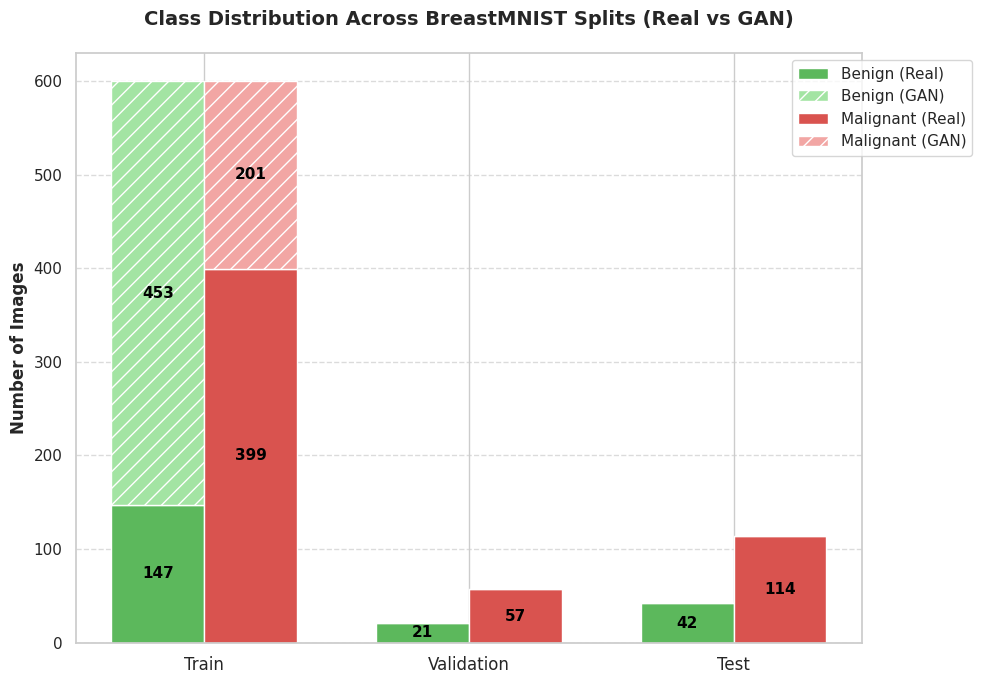

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def get_label_counts(dataset):
    labels = []
    for _, label in dataset:
        if isinstance(label, torch.Tensor):
            labels.append(label.item())
        elif isinstance(label, list) or hasattr(label, '__iter__'):
            labels.append(label[0])
        else:
            labels.append(label)
    return pd.Series(labels).value_counts()

val_counts = get_label_counts(val_dataset)
test_counts = get_label_counts(test_dataset)

train_real_benign = len(balanced_train_dataset.datasets[0])
train_real_malignant = len(balanced_train_dataset.datasets[1])
train_gan_benign = len(balanced_train_dataset.datasets[2])
train_gan_malignant = len(balanced_train_dataset.datasets[3])

splits = ['Train', 'Validation', 'Test']


benign_real = [train_real_benign, val_counts.get(0, 0), test_counts.get(0, 0)]
benign_gan = [train_gan_benign, 0, 0]

malignant_real = [train_real_malignant, val_counts.get(1, 0), test_counts.get(1, 0)]
malignant_gan = [train_gan_malignant, 0, 0]

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

color_benign_real = '#5cb85c'
color_benign_gan = '#a3e4a3'
color_malignant_real = '#d9534f'
color_malignant_gan = '#f2a6a4'

bar1 = ax.bar(x - width/2, benign_real, width, label='Benign (Real)', color=color_benign_real, edgecolor='white')
bar2 = ax.bar(x - width/2, benign_gan, width, bottom=benign_real, label='Benign (GAN)', color=color_benign_gan, edgecolor='white', hatch='//')

bar3 = ax.bar(x + width/2, malignant_real, width, label='Malignant (Real)', color=color_malignant_real, edgecolor='white')
bar4 = ax.bar(x + width/2, malignant_gan, width, bottom=malignant_real, label='Malignant (GAN)', color=color_malignant_gan, edgecolor='white', hatch='//')

ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution Across BreastMNIST Splits (Real vs GAN)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=12)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)

for container in [bar1, bar2, bar3, bar4]:
    for p in container:
        height = p.get_height()
        if height > 0:

            ax.annotate(f"{int(height)}",
                        (p.get_x() + p.get_width() / 2., p.get_y() + height / 2.),
                        ha='center', va='center',
                        fontsize=11, fontweight='bold', color='black')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [77]:
val_dataset = datasets.ImageFolder(os.path.join(base_dir, 'val'), transform=resnet_transform)
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), transform=resnet_transform)
final_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
final_test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

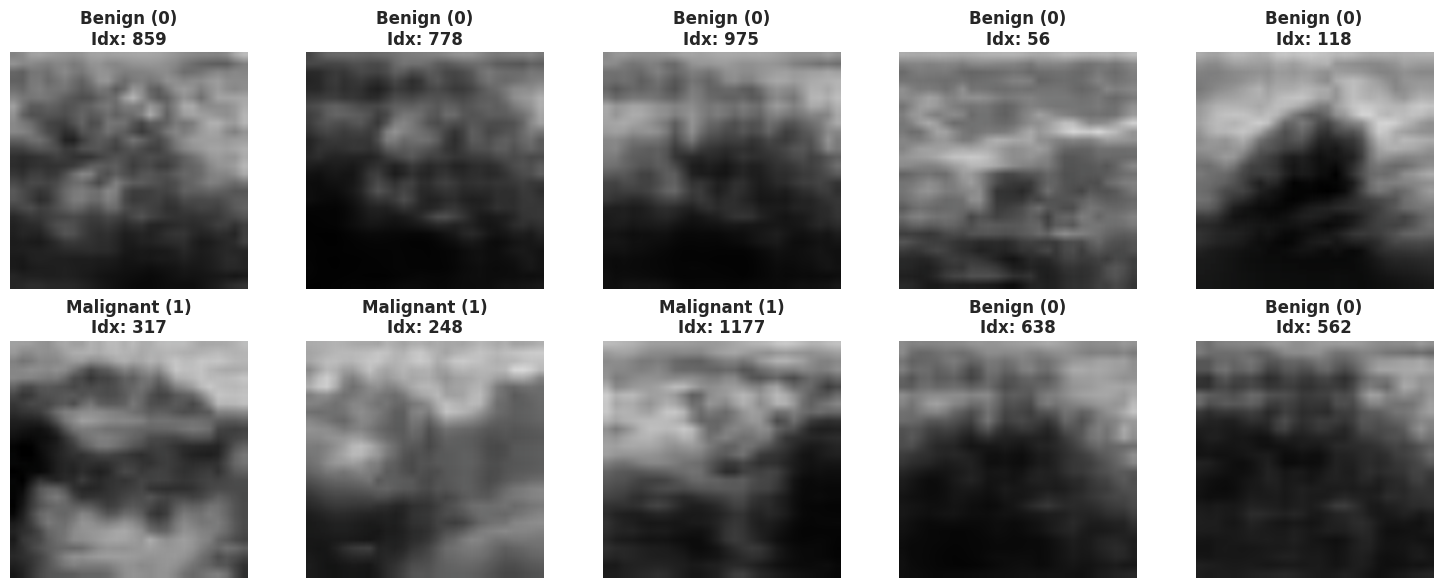

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_10_random_train_samples(dataset):
    random_indices = np.random.choice(len(dataset), 10, replace=False)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i, idx in enumerate(random_indices):
        image_tensor, label = dataset[idx]

        if isinstance(label, torch.Tensor):
            label_val = label.item()
        elif isinstance(label, (np.ndarray, list)):
            label_val = label[0]
        else:
            label_val = label

        image_np = image_tensor.numpy().transpose((1, 2, 0))

        image_unnorm = (std * image_np) + mean

        image_unnorm = np.clip(image_unnorm, 0, 1)

        axes[i].imshow(image_unnorm)

        class_name = "Malignant (1)" if label_val == 1 else "Benign (0)"
        axes[i].set_title(f"{class_name}\nIdx: {idx}", fontsize=12, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

show_10_random_train_samples(balanced_train_dataset)

In [79]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

epochs = 10
train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []
best_val_loss = float('inf')

print(f"\nStarting ResNet Training for {epochs} Epochs on {device}...")

for epoch in range(epochs):

    model.train()
    running_corrects = 0
    running_loss = 0.0
    total_train = 0

    for inputs, targets in final_train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == targets)
        running_loss += loss.item() * inputs.size(0)
        total_train += targets.size(0)

    train_acc = running_corrects.double() / total_train
    train_loss = running_loss / total_train

    train_acc_history.append(train_acc.item())
    train_loss_history.append(train_loss)

    model.eval()
    val_corrects = 0
    val_loss = 0.0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in final_val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == targets)
            val_loss += loss.item() * inputs.size(0)
            total_val += targets.size(0)

    val_acc = val_corrects.double() / total_val
    epoch_val_loss = val_loss / total_val

    val_acc_history.append(val_acc.item())
    val_loss_history.append(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.6f} | Val Loss: {epoch_val_loss:.6f} | Val Acc: {val_acc:.6f}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_breast_mnist_model_resnet.pth')
        print("  Best ResNet model saved!")


Starting ResNet Training for 10 Epochs on cuda...
Epoch [1/10] | Train Loss: 0.433929 | Train Acc: 0.845000 | Val Loss: 0.600171 | Val Acc: 0.730769
  Best ResNet model saved!
Epoch [2/10] | Train Loss: 0.256432 | Train Acc: 0.976667 | Val Loss: 0.635447 | Val Acc: 0.743590
Epoch [3/10] | Train Loss: 0.214983 | Train Acc: 1.000000 | Val Loss: 0.515769 | Val Acc: 0.782051
  Best ResNet model saved!
Epoch [4/10] | Train Loss: 0.206885 | Train Acc: 1.000000 | Val Loss: 0.431450 | Val Acc: 0.833333
  Best ResNet model saved!
Epoch [5/10] | Train Loss: 0.204218 | Train Acc: 1.000000 | Val Loss: 0.397435 | Val Acc: 0.871795
  Best ResNet model saved!
Epoch [6/10] | Train Loss: 0.202270 | Train Acc: 1.000000 | Val Loss: 0.412132 | Val Acc: 0.871795
Epoch [7/10] | Train Loss: 0.203658 | Train Acc: 1.000000 | Val Loss: 0.407551 | Val Acc: 0.871795
Epoch [8/10] | Train Loss: 0.202669 | Train Acc: 1.000000 | Val Loss: 0.408483 | Val Acc: 0.858974
Epoch [9/10] | Train Loss: 0.203233 | Train Acc: 

In [ ]:
from sklearn.metrics import classification_report
import torch

def get_clinical_report(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())


    print(classification_report(all_targets, all_preds, target_names=['Benign (0)', 'Malignant (1)']))


print("Clinical Evaluation Report:")

In [81]:
get_clinical_report(model, final_test_loader, device)

               precision    recall  f1-score   support

   Benign (0)       0.80      0.57      0.67        42
Malignant (1)       0.86      0.95      0.90       114

     accuracy                           0.85       156
    macro avg       0.83      0.76      0.78       156
 weighted avg       0.84      0.85      0.84       156

